In [2]:
import pandas as pd
import matplotlib.pyplot as plt

https://data.mendeley.com/datasets/574v66hf2v/1

# Collecting data

In [3]:
df = pd.read_csv("../datasets/PRDECT-ID Dataset.csv")
df.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


# SPLITTING DATASET

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
strat_train_set, strat_test_set = train_test_split(df, test_size=0.2, 
random_state=42, stratify=df["Category"])

In [6]:
print("stratified test set")
print(strat_test_set["Category"].value_counts() / len(strat_test_set))


stratified test set
Category
Phones and Tablets          0.037037
Office & Stationery         0.037037
Other Products              0.037037
Muslim Fashion              0.037037
Electronics                 0.037037
Movies and Music            0.037037
Food and Drink              0.037037
Computers and Laptops       0.037037
Toys and Hobbies            0.037037
Gaming                      0.037037
Carpentry                   0.037037
Body Care                   0.037037
Animal Care                 0.037037
Kids and Baby Fashion       0.037037
Men's Fashion               0.037037
Automotive                  0.037037
Sport                       0.037037
Party Supplies and Craft    0.037037
Household                   0.037037
Beauty                      0.037037
Camera                      0.037037
Women's Fashion             0.037037
Health                      0.037037
Kitchen                     0.037037
Mother and Baby             0.037037
Books                       0.037037
Precious 

In [7]:
print(strat_test_set["Category"].value_counts() / len(strat_test_set))

Category
Phones and Tablets          0.037037
Office & Stationery         0.037037
Other Products              0.037037
Muslim Fashion              0.037037
Electronics                 0.037037
Movies and Music            0.037037
Food and Drink              0.037037
Computers and Laptops       0.037037
Toys and Hobbies            0.037037
Gaming                      0.037037
Carpentry                   0.037037
Body Care                   0.037037
Animal Care                 0.037037
Kids and Baby Fashion       0.037037
Men's Fashion               0.037037
Automotive                  0.037037
Sport                       0.037037
Party Supplies and Craft    0.037037
Household                   0.037037
Beauty                      0.037037
Camera                      0.037037
Women's Fashion             0.037037
Health                      0.037037
Kitchen                     0.037037
Mother and Baby             0.037037
Books                       0.037037
Precious Metal              0

# EDA

In [8]:
import copy

In [9]:
df_eda = copy.deepcopy(strat_train_set)

In [10]:
df_eda.describe()

,Price,Overall Rating,Number Sold,Total Review,Customer Rating
count,4.320000e+03,4320.000000,4320.000000,4320.000000,4320.000000
mean,2.545836e+05,4.854468,16227.352778,2153.595139,3.096759
std,8.597411e+05,0.108190,75908.844838,2909.786164,1.770167
min,1.000000e+02,4.100000,9.000000,4.000000,1.000000
25%,2.000000e+04,4.800000,1565.000000,576.750000,1.000000
50%,6.000000e+04,4.900000,3760.000000,1172.000000,3.000000
75%,1.547500e+05,4.900000,9739.000000,2561.000000,5.000000
max,1.539900e+07,5.000000,1000000.000000,24500.000000,5.000000


array([[<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Overall Rating'}>],
       [<Axes: title={'center': 'Number Sold'}>, <Axes: >]], dtype=object)

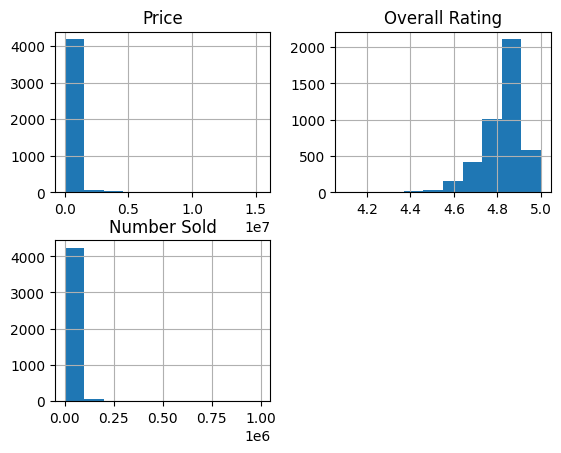

In [11]:
df_eda.hist(column=["Price", "Overall Rating", "Number Sold"])

Price dan Number Sold memiliki skewness

In [12]:
corr_matrix = df_eda.corr(numeric_only=True)

In [13]:
corr_matrix["Number Sold"].sort_values(ascending=False)

Number Sold        1.000000
Total Review       0.163960
Overall Rating     0.011704
Price             -0.048264
Customer Rating   -0.062012
Name: Number Sold, dtype: float64

rata-rata rating (Overall Rating) memiliki korelasi dengan Number Sold. 
Begitupun dengan price, meskipun negatif korelasinya, artinya semakin kecil Price 
semakin banyak pembelinya.

<Axes: xlabel='Overall Rating', ylabel='Number Sold'>

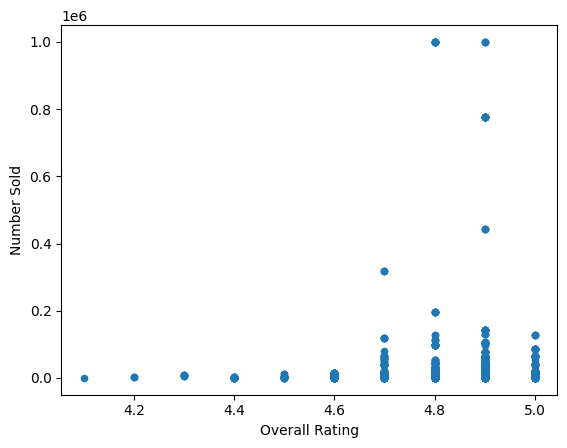

In [14]:
df_eda.plot(kind="scatter", x="Overall Rating", y="Number Sold")

<Axes: xlabel='Price', ylabel='Number Sold'>

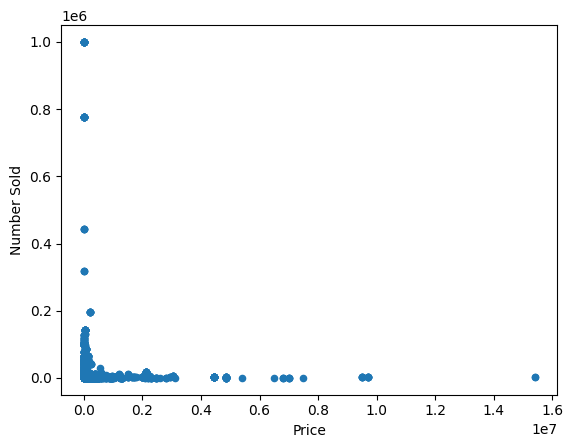

In [15]:
df_eda.plot(kind="scatter", x="Price", y="Number Sold")

# Data Pre-Processing

In [16]:
print(strat_train_set.columns)

Index(['Category', 'Product Name', 'Location', 'Price', 'Overall Rating',
       'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review',
       'Sentiment', 'Emotion'],
      dtype='str')


In [17]:
df = copy.deepcopy(strat_train_set)
df = df.drop(strat_train_set.columns[1:3], axis=1)
df = df.drop(strat_train_set.columns[6:], axis=1)


In [18]:
df.head()

,Category,Price,Overall Rating,Number Sold
4201,Kids and Baby Fashion,9000,4.9,15200
4055,Kitchen,359000,4.9,3890
1474,Party Supplies and Craft,7900,4.8,19800
1309,Body Care,72300,5.0,9695
2917,Men's Fashion,149000,4.9,1413


In [19]:
strat_test_set = strat_test_set.drop(strat_test_set.columns[1:3], axis=1)
strat_test_set = strat_test_set.drop(strat_test_set.columns[6:], axis=1)
strat_test_set = strat_test_set.drop(["Total Review", "Customer Rating"], axis=1)

In [20]:
strat_test_set.head()

,Category,Price,Overall Rating,Number Sold
3395,Phones and Tablets,150000,4.7,449
651,Office & Stationery,23000,4.8,1232
1955,Other Products,60500,5.0,1664
4355,Muslim Fashion,27000,4.8,10700
2649,Electronics,2499000,4.9,536


In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 4320 entries, 4201 to 4958
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        4320 non-null   str    
 1   Price           4320 non-null   int64  
 2   Overall Rating  4320 non-null   float64
 3   Number Sold     4320 non-null   int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 168.8 KB


In [22]:
display(df.isnull().sum())


Category          0
Price             0
Overall Rating    0
Number Sold       0
dtype: int64

<Axes: >

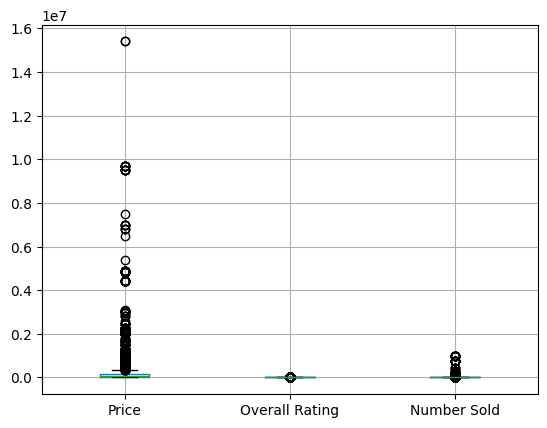

In [23]:
df.boxplot()

In [24]:
from sklearn.preprocessing import PowerTransformer

In [25]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ('num',  PowerTransformer(standardize=True), ["Price", "Overall Rating"]),    
    ('cat',    OneHotEncoder(sparse_output=False), ["Category"]),
], remainder='passthrough', verbose_feature_names_out=False)



In [26]:
df_labels = df["Number Sold"]
df = df.drop(columns=["Number Sold"])

In [ ]:
df.head()

,Category,Price,Overall Rating
4201,Kids and Baby Fashion,9000,4.9
4055,Kitchen,359000,4.9
1474,Party Supplies and Craft,7900,4.8
1309,Body Care,72300,5.0
2917,Men's Fashion,149000,4.9


In [28]:
df_labels.head()

4201    15200
4055     3890
1474    19800
1309     9695
2917     1413
Name: Number Sold, dtype: int64

# Training

**Linear Regression**

In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import make_pipeline



In [30]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(
    preprocessor,
    TransformedTargetRegressor(
        regressor=LinearRegression(),
        transformer=PowerTransformer()
    )
)
lin_reg.fit(df, df_labels)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('transformedtargetregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

In [34]:
pred = lin_reg.predict(df)
print(pred[:5])
print()
print( df_labels[:5])

[ 3834.6379525   2890.66583837  6322.49759289 11176.10649882
  1510.20956402]

4201    15200
4055     3890
1474    19800
1309     9695
2917     1413
Name: Number Sold, dtype: int64


In [35]:
lin_reg_rmse = root_mean_squared_error(df_labels, pred)
lin_reg_rmse

71916.06176858615

In [36]:
from sklearn.model_selection import cross_val_score

lin_reg_rmses = cross_val_score(lin_reg, df, df_labels, 
                             scoring="neg_root_mean_squared_error", cv=10)
pd.Series(-lin_reg_rmses).describe()

count       10.000000
mean     70836.479591
std      12842.528102
min      53173.862416
25%      61252.985582
50%      67311.220481
75%      79098.859292
max      90346.011569
dtype: float64

**DECISION TREE**

In [37]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline
tree_reg = make_pipeline(preprocessor, DecisionTreeRegressor(random_state=42))
tree_reg.fit(df, df_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of t

In [38]:
pred = tree_reg.predict(df)
print(pred[:5])

[15200.  3890. 19800.  9695.  1413.]


In [39]:
tree_rmse = root_mean_squared_error(df_labels, pred)
tree_rmse

3074.7130618790334

In [40]:

tree_rmses = cross_val_score(tree_reg, df, df_labels, 
                             scoring="neg_root_mean_squared_error", cv=10)
pd.Series(-tree_rmses).describe()

count       10.000000
mean     13828.938305
std      15382.475273
min       2911.025615
25%       4060.307313
50%       6454.923439
75%      14798.479553
max      47779.192447
dtype: float64

**Random Forrest**

In [41]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessor, RandomForestRegressor(random_state=42))

In [42]:
forest_rmses = -cross_val_score(forest_reg, df, df_labels, 
                                scoring="neg_root_mean_squared_error", cv=10)
pd.Series(forest_rmses).describe()

count       10.000000
mean     14187.812789
std      14684.599944
min       4750.691937
25%       5299.498260
50%       6879.747283
75%      13214.686820
max      46881.813109
dtype: float64

# Fine Tuning

**Grid Seach**

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [44]:
full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("random_forest", RandomForestRegressor(random_state=42))
])

In [45]:
param_grid = [
    {
      'random_forest__max_features': ['sqrt', 'log2', 0.3, 0.5, None]    
    }
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
scoring='neg_root_mean_squared_error')

In [46]:
grid_search.fit(df, df_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'random_forest__max_features': ['sqrt', 'log2', ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [49]:
grid_search.best_params_

{'random_forest__max_depth': None,
 'random_forest__max_features': 'sqrt',
 'random_forest__n_estimators': 300}

In [47]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
2,0.538934,0.005661,0.045382,0.002211,0.3,{'random_forest__max_features': 0.3},-17300.208262,-20632.548415,-23433.196175,-20455.317618,2506.916200,1
1,0.445501,0.006115,0.046565,0.000880,log2,{'random_forest__max_features': 'log2'},-17421.562412,-20655.434919,-23562.889739,-20546.629023,2508.366583,2
0,0.486054,0.021625,0.046577,0.001272,sqrt,{'random_forest__max_features': 'sqrt'},-18679.490853,-20579.547836,-23454.397898,-20904.478862,1962.841384,3
3,0.660592,0.010021,0.045833,0.000235,0.5,{'random_forest__max_features': 0.5},-18478.045860,-20797.482243,-23522.500313,-20932.676138,2061.607500,4
4,1.054290,0.009184,0.046309,0.001976,None,{'random_forest__max_features': None},-27244.404102,-21183.178508,-24040.722492,-24156.101700,2475.829585,5


**Randomized Search**

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
'random_forest__max_features': randint(low=2, high=20)}
rnd_search = RandomizedSearchCV(
full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
scoring='neg_root_mean_squared_error', random_state=42)
rnd_search.fit(df, df_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'random_forest__max_features': <scipy.stats....00250A5C79010>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if

In [49]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
8,0.534534,0.008450,0.048150,0.002839,9,{'random_forest__max_features': 9},-17300.208262,-20632.548415,-23433.196175,-20455.317618,2506.916200,1
3,0.549254,0.025677,0.045117,0.000322,9,{'random_forest__max_features': 9},-17300.208262,-20632.548415,-23433.196175,-20455.317618,2506.916200,1
9,0.432088,0.009947,0.045428,0.000721,4,{'random_forest__max_features': 4},-17421.562412,-20655.434919,-23562.889739,-20546.629023,2508.366583,3
5,0.597265,0.003709,0.045502,0.001001,12,{'random_forest__max_features': 12},-17820.327503,-20669.479557,-23405.284953,-20631.697338,2280.205846,4
6,0.598022,0.002021,0.046205,0.001330,12,{'random_forest__max_features': 12},-17820.327503,-20669.479557,-23405.284953,-20631.697338,2280.205846,4


In [52]:
final_model = rnd_search.best_estimator_

In [54]:
pred = final_model.predict(df)
print(pred[:5])
print()
print(df_labels[:5])

[15200.    3890.   19800.    9235.21  1403.07]

4201    15200
4055     3890
1474    19800
1309     9695
2917     1413
Name: Number Sold, dtype: int64


In [55]:
final_model_rmses = -cross_val_score(final_model, df, df_labels, 
                                scoring="neg_root_mean_squared_error", cv=10)
pd.Series(final_model_rmses).describe()

count       10.000000
mean     11080.250443
std      10151.550795
min       3307.579807
25%       4931.383758
50%       6753.646729
75%      11257.466316
max      34823.366767
dtype: float64

# Evaluate

In [59]:
X_test = strat_test_set.drop("Number Sold", axis=1)
y_test = copy.copy(strat_test_set.iloc[:, -1])

In [60]:
X_test.head()


,Category,Price,Overall Rating
3395,Phones and Tablets,150000,4.7
651,Office & Stationery,23000,4.8
1955,Other Products,60500,5.0
4355,Muslim Fashion,27000,4.8
2649,Electronics,2499000,4.9


In [61]:
y_test.head()

3395      449
651      1232
1955     1664
4355    10700
2649      536
Name: Number Sold, dtype: int64

In [62]:
final_predictions = final_model.predict(X_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

7200.887902923511


In [63]:
import numpy as np

In [64]:
from scipy import stats
def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

In [65]:
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse,
confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval

# Save Model

In [66]:
import joblib

joblib.dump(final_model, "e-commerce_analysis_regression_model.pkl")

['e-commerce_analysis_regression_model.pkl']